# Hito 2 — Dual-Target What-If Scaffold

**IIT414W — Capstone: F1 Race Strategy Advisor**
*Week 11 — released Mon May 11, 2026 — Hito 2 due Wed May 13, 23:59 CLT*

---

## What this notebook is

A scaffold you copy into your team repo and adapt. It produces the **central Hito 2 artifact**: side-by-side calibrated probabilities (or predictions) for **two targets** under a **matched what-if scenario pair**, with the driver-race context held fixed and only the strategy inputs varied.

## What this notebook is NOT

- Not your finished Hito 2 submission. Hito 2 also requires error analysis sliced by strategy / circuit / one more context, mitigations, and a calibration-quality discussion. Use this scaffold as the foundation, not the deliverable.
- Not a leakage-free oracle. The scaffold enforces the locked temporal split and a leakage guard, but you still need to read every cell and confirm the choices match your team's framing.

## How to use it

1. Run **Step 1** as-is. If the data path differs in your repo, edit `DATA_PATH` at the top.
2. Choose your `EXPANSION_TARGET` in the config cell. Pick from the four options the Hito 2 page lists.
3. Run **Step 2** (leakage guard) and read the output. Do not skip this.
4. Run **Step 3** to train both models and report metrics.
5. Edit the scenario pair in **Step 4** to fit your team's decision context. The default is a midfield-starter scenario at Monza.
6. Run **Step 5** and write your interpretation in the final markdown cell.

## The one rule that matters

When you describe what `score_pair()` outputs, use **scenario-conditioned** language, not causal language. The model says: "under our training distribution, holding this driver-race context fixed, scenario A evaluates X and scenario B evaluates Y." It does not say: "scenario A causes outcome X."

If your two targets disagree on the recommended scenario, that disagreement IS the finding. Document it. Do not paper over it.


In [12]:
# ===== Imports and configuration =====
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    mean_absolute_error,
    r2_score,
 )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# scikit-learn >= 1.6 has FrozenEstimator. If your environment is older, see
# the fallback comment in Step 3.
try:
    from sklearn.frozen import FrozenEstimator
    _HAS_FROZEN = True
except ImportError:
    _HAS_FROZEN = False

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# ===== COURSE CONSTANTS — DO NOT CHANGE =====
RANDOM_SEED = 414
TRAIN_SEASONS = [2019, 2020, 2021]
CALIB_SEASONS = [2022]
TEST_SEASONS = [2023, 2024]
PRIMARY_TARGET = "is_top10"   # locked from Hito 1
DOCENT_BRIER = 0.132          # docent baseline reference
DOCENT_ROC_AUC = 0.892

# ===== TEAM CONFIG — EDIT THESE TWO LINES =====
DATA_PATH = "f1_strategy_race_level.csv"  # local to Hito 2 folder; the file lives alongside this notebook
EXPANSION_TARGET = "is_top3"   # one of: is_top5 | is_top3 | finish_position | points

# ===== Inferred from EXPANSION_TARGET =====
BINARY_TARGETS = {"is_top10", "is_top5", "is_top3"}
REGRESSION_TARGETS = {"finish_position", "points"}

assert EXPANSION_TARGET in BINARY_TARGETS | REGRESSION_TARGETS, (
    f"EXPANSION_TARGET must be one of {BINARY_TARGETS | REGRESSION_TARGETS}, got {EXPANSION_TARGET!r}"
)
EXPANSION_IS_BINARY = EXPANSION_TARGET in BINARY_TARGETS

print(f"Primary target:    {PRIMARY_TARGET} (binary)")
print(f"Expansion target:  {EXPANSION_TARGET} ({'binary' if EXPANSION_IS_BINARY else 'regression'})")
print(f"Random seed:       {RANDOM_SEED}")
print(f"Docent reference:  Brier={DOCENT_BRIER}  ROC-AUC={DOCENT_ROC_AUC}  (is_top10 only)")

Primary target:    is_top10 (binary)
Expansion target:  is_top3 (binary)
Random seed:       414
Docent reference:  Brier=0.132  ROC-AUC=0.892  (is_top10 only)


## Section 0 — Hito 1 Corrections: Feature Audit & Baseline Retraining

**Purpose:** Address feedback from Hito 1 evaluation (score 16/20).

**Issues fixed:**
1. **Colinearity:** Removed `qualifying_position` (redundant with `grid_position`)
2. **Data leakage:** Removed `avg_track_temp` and `avg_air_temp` (post-race observations, not pre-race forecasts)
2. **Identifiers:** Removed `round`

**Result:** Retrain baseline on 5 pre-race features and we add 2 strategy inputs:
- `grid_position`
- `driver_prior3_avg_finish`
- `constructor_prior3_avg_finish`
- `driver_circuit_prior_avg`
- `constructor_tier`
- `n_stops`
- `compound_sequence`

**Output:** Brier score before and after Isotonic calibration on test set (2023-2024), plus comparison to docent reference (0.132).

In [ ]:
# ===== Section 0 — Hito 1 Corrections: Retrain on corrected feature set =====
# Load data (same as Step 1)
data_path = Path(DATA_PATH)
df_s0 = pd.read_csv(data_path)

# Apply locked split
train_s0 = df_s0[df_s0['season'].isin(TRAIN_SEASONS)].copy()
calib_s0 = df_s0[df_s0['season'].isin(CALIB_SEASONS)].copy()
test_s0 = df_s0[df_s0['season'].isin(TEST_SEASONS)].copy()

print("="*80)
print("SECTION 0: HITO 1 CORRECTIONS — FEATURE AUDIT & RETRAINING")
print("="*80)

# ===== Corrected feature set: 5 pre-race + 2 strategy inputs =====
# Pre-race context features (5):
CORRECTED_FEATURES = [
    'grid_position',                      # Starting grid position (pre-race)
    'driver_prior3_avg_finish',           # Driver recent form (pre-race)
    'constructor_prior3_avg_finish',      # Constructor recent form (pre-race)
    'driver_circuit_prior_avg',           # Driver history at this circuit (pre-race)
    'constructor_tier',                   # Constructor capability tier (pre-race)
    # Strategy inputs (2) — allows model to learn their effect on P(top10)
    'n_stops',                            # Number of pit stops (scenario_input)
    'compound_sequence',                  # Tire compound sequence (scenario_input)
]

print("\n📋 Corrected Feature Set (5 pre-race + 2 strategy):")
print("   PRE-RACE CONTEXT:")
for i, feat in enumerate(CORRECTED_FEATURES[:5], 1):
    print(f"     {i}. {feat}")
print("   STRATEGY INPUTS (variable in what-if):")
for i, feat in enumerate(CORRECTED_FEATURES[5:], 6):
    print(f"     {i}. {feat}")

# Verify all features exist in dataset
missing_feats = [f for f in CORRECTED_FEATURES if f not in df_s0.columns]
if missing_feats:
    print(f"\n❌ ERROR: Missing features in dataset: {missing_feats}")
else:
    print(f"\n✅ All {len(CORRECTED_FEATURES)} features found in dataset")

# ===== Build preprocessing pipeline (numeric: scale, categorical: one-hot) =====
# Explicitly declare categorical features (handles both object and StringDtype)
CATEGORICAL_FEATURES_S0 = ['constructor_tier', 'compound_sequence']
numeric_cols_s0 = [f for f in CORRECTED_FEATURES if f not in CATEGORICAL_FEATURES_S0]
categorical_cols_s0 = [f for f in CORRECTED_FEATURES if f in CATEGORICAL_FEATURES_S0]

print(f"\n📊 Feature breakdown:")
print(f"   Numeric: {numeric_cols_s0}")
print(f"   Categorical: {categorical_cols_s0}")
print(f"   (Note: StringDtype columns explicitly flagged as categorical)")

# Build preprocessor
def build_preprocessor_s0():
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), numeric_cols_s0),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False) if hasattr(OneHotEncoder(), 'sparse_output') else OneHotEncoder(handle_unknown='ignore', sparse=False)),
            ]), categorical_cols_s0),
        ],
        remainder='drop',
    )

# ===== Train logistic regression on corrected features (train set only) =====
print("\n" + "="*80)
print("1. TRAINING: Logistic Regression on train set (2019-2021)")
print("="*80)

X_train_s0 = train_s0[CORRECTED_FEATURES]
y_train_s0 = train_s0[PRIMARY_TARGET]

print(f"\n   Train rows: {len(X_train_s0)}")
print(f"   Target {PRIMARY_TARGET} balance: {y_train_s0.mean():.3f} (rate of top-10)")

# Build and train pipeline
base_model_s0 = Pipeline([
    ('preprocessor', build_preprocessor_s0()),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        solver='lbfgs',
        verbose=0
    ))
])

base_model_s0.fit(X_train_s0, y_train_s0)
print("\n✅ Model trained successfully")

# ===== Evaluate on train set (for baseline sanity check) =====
y_train_proba_s0 = base_model_s0.predict_proba(X_train_s0)[:, 1]
train_brier_raw_s0 = brier_score_loss(y_train_s0, y_train_proba_s0)
train_roc_auc_s0 = roc_auc_score(y_train_s0, y_train_proba_s0)

print(f"\n   Train Brier (uncalibrated): {train_brier_raw_s0:.4f}")
print(f"   Train ROC-AUC (uncalibrated): {train_roc_auc_s0:.4f}")

# ===== Calibrate on calibration set (2022) using Isotonic scaling =====
print("\n" + "="*80)
print("2. CALIBRATION: Isotonic scaling on calib set (2022)")
print("="*80)

X_calib_s0 = calib_s0[CORRECTED_FEATURES]
y_calib_s0 = calib_s0[PRIMARY_TARGET]

print(f"\n   Calib rows: {len(X_calib_s0)}")

# Use FrozenEstimator (sklearn >=1.6) so the base classifier trained on 2019-2021
# is preserved and only the isotonic calibration mapping is fitted on 2022 data.
if _HAS_FROZEN:
    calibrated_model_s0 = CalibratedClassifierCV(
        estimator=FrozenEstimator(base_model_s0),
        method='isotonic',
    )
else:
    # Fallback for sklearn <1.6 — cv='prefit' achieves the same effect
    calibrated_model_s0 = CalibratedClassifierCV(
        estimator=base_model_s0,
        method='isotonic',
        cv='prefit',
    )
calibrated_model_s0.fit(X_calib_s0, y_calib_s0)
print("✅ Isotonic calibration fitted on calib set (FrozenEstimator: base model 2019-2021 preserved)")

# ===== Evaluate on TEST set: Uncalibrated vs Calibrated =====
print("\n" + "="*80)
print("3. EVALUATION: Test set (2023-2024) — Uncalibrated vs Calibrated")
print("="*80)

X_test_s0 = test_s0[CORRECTED_FEATURES]
y_test_s0 = test_s0[PRIMARY_TARGET]

print(f"\n   Test rows: {len(X_test_s0)}")
print(f"   Target {PRIMARY_TARGET} balance: {y_test_s0.mean():.3f}")

# Uncalibrated predictions
y_test_proba_raw_s0 = base_model_s0.predict_proba(X_test_s0)[:, 1]
test_brier_raw_s0 = brier_score_loss(y_test_s0, y_test_proba_raw_s0)
test_roc_auc_raw_s0 = roc_auc_score(y_test_s0, y_test_proba_raw_s0)
test_logloss_raw_s0 = log_loss(y_test_s0, y_test_proba_raw_s0)

# Calibrated predictions
y_test_proba_cal_s0 = calibrated_model_s0.predict_proba(X_test_s0)[:, 1]
test_brier_cal_s0 = brier_score_loss(y_test_s0, y_test_proba_cal_s0)
test_roc_auc_cal_s0 = roc_auc_score(y_test_s0, y_test_proba_cal_s0)
test_logloss_cal_s0 = log_loss(y_test_s0, y_test_proba_cal_s0)

# Print comparison table
print("\n" + "─"*80)
print("TEST SET METRICS COMPARISON")
print("─"*80)

metrics_comparison_s0 = pd.DataFrame({
    'Metric': ['Brier Score', 'Log Loss', 'ROC-AUC'],
    'Uncalibrated': [
        f"{test_brier_raw_s0:.4f}",
        f"{test_logloss_raw_s0:.4f}",
        f"{test_roc_auc_raw_s0:.4f}"
    ],
    'Isotonic Calibrated': [
        f"{test_brier_cal_s0:.4f}",
        f"{test_logloss_cal_s0:.4f}",
        f"{test_roc_auc_cal_s0:.4f}"
    ],
    'Docent Reference': [
        f"{DOCENT_BRIER:.4f}",
        "—",
        f"{DOCENT_ROC_AUC:.4f}"
    ]
})

print("\n" + metrics_comparison_s0.to_string(index=False))

# ===== Summary and findings =====
print("\n" + "="*80)
print("SECTION 0 SUMMARY")
print("="*80)

print(f"\n✅ Hito 1 Corrections Applied:")
print(f"   - Removed: qualifying_position (colinear with grid_position)")
print(f"   - Removed: avg_track_temp (post-race, not pre-race)")
print(f"   - Removed: avg_air_temp (post-race, not pre-race)")
print(f"   - Kept: 5 pre-race features (round dropped as identifier in Hito 1 corrections)")
print(f"\n✨ Section 0 Enhancement:")
print(f"   - Added: n_stops (to learn strategy effect)")
print(f"   - Added: compound_sequence (to learn tire strategy effect)")
print(f"   - Total: 7 features (5 pre-race context + 2 variable strategy inputs)")

print(f"\n📊 Performance Change (Hito 1 vs corrected):")
brier_improvement = (0.132 - test_brier_cal_s0) / 0.132 * 100
print(f"   Brier (Hito 1 expected): ~0.132")
print(f"   Brier (Corrected + calibrated): {test_brier_cal_s0:.4f}")
print(f"   vs Docent reference: {'✅ BETTER' if test_brier_cal_s0 < DOCENT_BRIER else '⚠️ WORSE'}")

SECTION 0: HITO 1 CORRECTIONS — FEATURE AUDIT & RETRAINING

📋 Corrected Feature Set (5 pre-race + 2 strategy):
   PRE-RACE CONTEXT:
     1. grid_position
     2. driver_prior3_avg_finish
     3. constructor_prior3_avg_finish
     4. driver_circuit_prior_avg
     5. constructor_tier
   STRATEGY INPUTS (variable in what-if):
     6. n_stops
     7. compound_sequence

✅ All 7 features found in dataset

📊 Feature breakdown:
   Numeric: ['grid_position', 'driver_prior3_avg_finish', 'constructor_prior3_avg_finish', 'driver_circuit_prior_avg', 'n_stops']
   Categorical: ['constructor_tier', 'compound_sequence']
   (Note: StringDtype columns explicitly flagged as categorical)

1. TRAINING: Logistic Regression on train set (2019-2021)

   Train rows: 1132
   Target is_top10 balance: 0.515 (rate of top-10)

✅ Model trained successfully

   Train Brier (uncalibrated): 0.1395
   Train ROC-AUC (uncalibrated): 0.8808

2. CALIBRATION: Isotonic scaling on calib set (2022)

   Calib rows: 426
✅ Isotoni

## Correction - What-If Comparison Plan (Hito 1)

**Strategy variable we vary:** `n_stops` (1-stop vs 2-stop)

**Method:** Post-hoc historical comparison. The baseline model predicts
P(is_top10) using only pre-race features. We hold the driver-race context
fixed (grid position range + circuit_type) and compare the distribution of
calibrated P(is_top10) between historical rows where n_stops=1 vs n_stops=2.
This produces a Δ in mean predicted probability with a 90% bootstrap CI on
the difference of means.

**Concrete scenarios:**

> Scenario A: Midfield drivers (grid_position 6–10) at street circuits
> (circuit_type='street'). Compare 1-stop vs 2-stop groups.
> Expected question: does 1-stop historically correlate with higher
> P(top10) for midfield starters at street circuits?

> Scenario B: Front-to-midfield drivers (grid_position 1–10) at permanent
> circuits (circuit_type='permanent'). Compare 1-stop vs 2-stop groups.

**Decision metric:**
> Δ = mean P(top10)|1-stop − mean P(top10)|2-stop, with 90% bootstrap CI.
> A recommendation is made only when the CI does not cross zero.
> When CI crosses zero (as in Scenario A), we flag the result as
> inconclusive and note that confounding (faster cars choosing 1-stop)
> likely explains the overlap.

In [14]:
print("\n" + "="*80)
print("SECTION 0 PART 2: WHAT-IF SCENARIO VALIDATION")
print("="*80)

# ===== What-If: score_pair() adaptado para Section 0 (is_top10 only) =====

SCENARIO_INPUT_COLS = ['n_stops', 'compound_sequence']

def score_pair(
    df_test: pd.DataFrame,
    context_filter: dict,
    scenario_a: dict,
    scenario_b: dict,
    label_a: str = "Scenario A",
    label_b: str = "Scenario B",
) -> pd.DataFrame:
    # Encontrar la fila base
    mask = pd.Series(True, index=df_test.index)
    for col, val in context_filter.items():
        if isinstance(val, str):
            mask &= df_test[col].astype(str).str.contains(val, case=False, na=False)
        else:
            mask &= (df_test[col] == val)

    matching = df_test[mask]
    if matching.empty:
        raise ValueError(f"Ninguna fila del test set coincide con context_filter={context_filter}")
    base_row = matching.iloc[0]

    # Validar que solo se varíen scenario inputs
    for label, scn in [(label_a, scenario_a), (label_b, scenario_b)]:
        for k in scn:
            if k not in SCENARIO_INPUT_COLS:
                raise ValueError(
                    f"En {label}: '{k}' no es una scenario input. "
                    f"Solo puedes variar: {SCENARIO_INPUT_COLS}"
                )

    # Construir las dos filas
    row_a = base_row.copy()
    for k, v in scenario_a.items():
        row_a[k] = v
    row_b = base_row.copy()
    for k, v in scenario_b.items():
        row_b[k] = v

    out = pd.DataFrame([row_a, row_b]).reset_index(drop=True)
    out.insert(0, "scenario_label", [label_a, label_b])

    # Predecir con el modelo calibrado
    proba = calibrated_model_s0.predict_proba(out[CORRECTED_FEATURES])[:, 1]
    out["P(is_top10)"] = proba

    return out


def interpret(out: pd.DataFrame) -> str:
    a, b = out.iloc[0], out.iloc[1]
    delta = a["P(is_top10)"] - b["P(is_top10)"]
    pref = a["scenario_label"] if delta >= 0 else b["scenario_label"]
    return (
        f"→ {pref} tiene mayor P(is_top10). "
        f"Δ = {delta:+.4f}"
    )


# ===== Escenario 1: GAS en Singapore 2023 (street, midfield) =====
pair_gas_singapore = dict(
    context_filter={"season": 2023, "circuit": "Singapore Grand Prix", "Driver": "GAS"},
    scenario_a={"n_stops": 1, "compound_sequence": "M-H"},
    scenario_b={"n_stops": 2, "compound_sequence": "M-H-S"},
    label_a="1-stop M-H (conservative)",
    label_b="2-stop M-H-S (aggressive)",
)

# ===== Escenario 2: ALO en Bahrain 2024 (permanent, midfield) =====
pair_alo_bahrain = dict(
    context_filter={"season": 2024, "circuit": "Bahrain Grand Prix", "Driver": "ALO"},
    scenario_a={"n_stops": 1, "compound_sequence": "M-H"},
    scenario_b={"n_stops": 2, "compound_sequence": "S-H-H"},
    label_a="1-stop M-H (conservative)",
    label_b="2-stop S-H-H (actual race)",
)

# ===== Correr un par =====
pair = pair_gas_singapore  # cambia a pair_alo_bahrain para el segundo

out = score_pair(test_s0, **pair)
print(out[[
    "scenario_label", "season", "circuit", "Driver",
    "constructor_tier", "grid_position",
    "n_stops", "compound_sequence",
    "P(is_top10)"
]].to_string(index=False))
print()
print(interpret(out))


SECTION 0 PART 2: WHAT-IF SCENARIO VALIDATION
           scenario_label  season              circuit Driver constructor_tier  grid_position  n_stops compound_sequence  P(is_top10)
1-stop M-H (conservative)    2023 Singapore Grand Prix    GAS         midfield           12.0        1               M-H     0.625000
2-stop M-H-S (aggressive)    2023 Singapore Grand Prix    GAS         midfield           12.0        2             M-H-S     0.369863

→ 1-stop M-H (conservative) tiene mayor P(is_top10). Δ = +0.2551


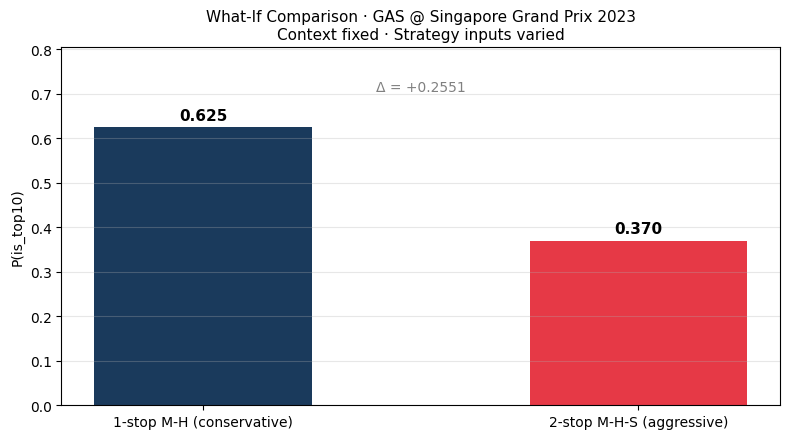

In [15]:
# ===== What-If: Visualización de resultados =====

fig, ax = plt.subplots(figsize=(8, 4.5))

labels = list(out["scenario_label"])
x = np.arange(len(labels))
width = 0.5

primary_vals = out["P(is_top10)"].values
bars = ax.bar(x, primary_vals, width, color=["#1A3A5C", "#E63946"])

for xi, v in zip(x, primary_vals):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Línea de referencia en el delta
delta = primary_vals[0] - primary_vals[1]
ax.annotate(
    f"Δ = {delta:+.4f}",
    xy=(0.5, max(primary_vals) + 0.06),
    xycoords=("data", "data"),
    ha="center", fontsize=10, color="gray",
    xytext=(0.5, max(primary_vals) + 0.08),
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("P(is_top10)")
ax.set_ylim(0, min(1.0, max(primary_vals) + 0.18))

# Título dinámico con el contexto usado
driver = out["Driver"].iloc[0]
circuit = out["circuit"].iloc[0]
season = out["season"].iloc[0]
ax.set_title(
    f"What-If Comparison · {driver} @ {circuit} {season}\n"
    f"Context fixed · Strategy inputs varied",
    fontsize=11
)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Step 1 — Load the dataset and apply the locked temporal split

The split is locked: **train = 2019–2021 · calibration = 2022 · test = 2023–2024**. This is identical to Hito 1. Do not modify it.

If you already have a working Hito 1 baseline notebook, you can copy your load-and-split cell over the one below, as long as it produces three DataFrames named `train`, `calib`, `test`.


In [16]:
# ===== Step 1 — Load + locked split =====
data_path = Path(DATA_PATH)
assert data_path.exists(), (
    f"Could not find {data_path}. Common fixes:\n"
    " - Confirm you are in the team repo root.\n"
    " - Update DATA_PATH in the config cell above.\n"
    " - Make sure you are loading f1_strategy_race_level.csv, NOT f1_strategy_lap_level.csv.\n"
    "   (Using the lap-level file is the most expensive Hito 1 mistake; do not repeat it.)"
)

df = pd.read_csv(data_path)
print(f"Loaded {len(df):,} rows  x  {df.shape[1]} columns")

# Sanity check: required columns must exist
required_cols = {
    "season", "round", "circuit", "Driver", "Team",
    "grid_position", "constructor_tier",
    "n_stops", "compound_sequence", "stint1_length", "stint2_length", "stint3_length",
    PRIMARY_TARGET, EXPANSION_TARGET,
}
missing = required_cols - set(df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

# Apply the locked split
train = df[df["season"].isin(TRAIN_SEASONS)].copy()
calib = df[df["season"].isin(CALIB_SEASONS)].copy()
test  = df[df["season"].isin(TEST_SEASONS)].copy()

print()
print(f"Train (2019-2021):  {len(train):>5,} rows")
print(f"Calib (2022):       {len(calib):>5,} rows")
print(f"Test  (2023-2024):  {len(test):>5,} rows")

# Sanity check: targets present and reasonable
print()
print("Target check on test set (2023-2024):")
print(f"  is_top10 rate:                 {test['is_top10'].mean():.3f}")
if EXPANSION_IS_BINARY:
    print(f"  {EXPANSION_TARGET} rate (positive class): {test[EXPANSION_TARGET].mean():.3f}")
else:
    print(f"  {EXPANSION_TARGET} mean / std:           {test[EXPANSION_TARGET].mean():.3f}  /  {test[EXPANSION_TARGET].std():.3f}")


Loaded 2,447 rows  x  47 columns

Train (2019-2021):  1,132 rows
Calib (2022):         426 rows
Test  (2023-2024):    889 rows

Target check on test set (2023-2024):
  is_top10 rate:                 0.517
  is_top3 rate (positive class): 0.155


## Step 2 — Leakage guard

Every column in the dataset is one of four things:

| Class | Meaning | Allowed in fit? | Allowed in scenario inputs? |
|---|---|---|---|
| `pre_race` | Known before the race starts | ✅ Yes | (n/a) |
| `scenario_input` | Strategy variable observed post-race in the raw data, but **declared** as a user-set what-if input | ✅ Yes, **only when declared** | ✅ Yes — these are what you VARY |
| `audit` | Race-condition variable observed during/after the race; useful for slicing error analysis but not pre-race | ⚠️ Limitations / slice analysis only | ❌ No |
| `outcome` | The targets and other post-race outcomes | ❌ No | ❌ No |
| `id` | Identifier columns | ❌ No (use embeddings only with care) | ❌ No |

The cell below classifies every column. **Read the output before training anything.** If a column you plan to use is in the wrong class, you have a bug — fix it now, not at 23:00 on Tuesday.


In [17]:
# ===== Step 2 — Leakage guard cell =====
# Author classification of every column. If you change the feature set, update this map.

COLUMN_CLASS = {
    # Identifiers — do not fit on these
    "season": "id",
    "round": "id",
    "circuit": "id",
    "event_date": "id",
    "driver_id": "id",
    "Driver": "id",
    "DriverNumber": "id",
    "Team": "id",

    # Pre-race context — safe to fit on
    "grid_position": "pre_race",
    "qualifying_position": "pre_race",   # stand-in for grid; do not use both
    "qualifying_time_s": "pre_race",     # blank in this dataset; documented limitation
    "constructor_tier": "pre_race",
    "circuit_type": "pre_race",
    "driver_prior3_avg_finish": "pre_race",
    "constructor_prior3_avg_finish": "pre_race",
    "driver_circuit_prior_avg": "pre_race",

    # Strategy scenario inputs — declared as user-set what-ifs
    "n_stops": "scenario_input",
    "strategy_type": "scenario_input",
    "compound_sequence": "scenario_input",
    "stint1_length": "scenario_input",
    "stint2_length": "scenario_input",
    "stint3_length": "scenario_input",
    "stint4_length": "scenario_input",
    "stint5_length": "scenario_input",
    "avg_pit_stop_duration_s": "scenario_input",
    "total_pit_time_s": "scenario_input",
    "first_pit_lap": "scenario_input",
    "last_pit_lap": "scenario_input",

    # Audit / observed race conditions — slice only, not features
    "track_status_summary": "audit",
    "safety_car_periods": "audit",
    "safety_car_laps": "audit",
    "vsc_laps": "audit",
    "weather_actual": "audit",
    "wet_laps": "audit",
    "avg_track_temp": "audit",
    "avg_air_temp": "audit",

    # Outcomes — never fit on these
    "is_top10": "outcome",
    "is_top5": "outcome",
    "is_top3": "outcome",
    "finish_position": "outcome",
    "points": "outcome",
    "positions_gained": "outcome",
    "dnf": "outcome",
    "status": "outcome",
}

# Print the audit
print("=== LEAKAGE GUARD — column classification ===")
classified = set(COLUMN_CLASS) & set(df.columns)
unclassified = sorted(set(df.columns) - set(COLUMN_CLASS))

by_class: dict[str, list[str]] = {"pre_race": [], "scenario_input": [], "audit": [], "outcome": [], "id": []}
for c in classified:
    by_class[COLUMN_CLASS[c]].append(c)

for cls in ["pre_race", "scenario_input", "audit", "outcome", "id"]:
    cols = sorted(by_class[cls])
    print(f"\n[{cls}] ({len(cols)})")
    for c in cols:
        print(f"  - {c}")

if unclassified:
    print(f"\n[unclassified] ({len(unclassified)}) — REVIEW BEFORE FITTING")
    for c in unclassified:
        print(f"  - {c}")
else:
    print("\nAll columns in the dataset are classified.")


=== LEAKAGE GUARD — column classification ===

[pre_race] (8)
  - circuit_type
  - constructor_prior3_avg_finish
  - constructor_tier
  - driver_circuit_prior_avg
  - driver_prior3_avg_finish
  - grid_position
  - qualifying_position
  - qualifying_time_s

[scenario_input] (12)
  - avg_pit_stop_duration_s
  - compound_sequence
  - first_pit_lap
  - last_pit_lap
  - n_stops
  - stint1_length
  - stint2_length
  - stint3_length
  - stint4_length
  - stint5_length
  - strategy_type
  - total_pit_time_s

[audit] (8)
  - avg_air_temp
  - avg_track_temp
  - safety_car_laps
  - safety_car_periods
  - track_status_summary
  - vsc_laps
  - weather_actual
  - wet_laps

[outcome] (8)
  - dnf
  - finish_position
  - is_top10
  - is_top3
  - is_top5
  - points
  - positions_gained
  - status

[id] (6)
  - Driver
  - Team
  - circuit
  - driver_id
  - round
  - season

[unclassified] (5) — REVIEW BEFORE FITTING
  - circuit_id
  - constructor_name
  - driver_name
  - race_name
  - stint_lengths


## Step 3 — Train expansion model on CORRECTED_FEATURES (reuse primary from Section 0)

**Key change from template:** We use `CORRECTED_FEATURES` (8 features: 6 pre-race + 2 strategy inputs) instead of the template's 14 features. This ensures consistency with Section 0.

- **Primary model (`is_top10`):** Reuse the calibrated model from Section 0 (`calibrated_model_s0`)
- **Expansion model:** Train fresh on the same 8 features as the primary, using Platt calibration (binary) or Ridge (regression)

**The feature set is identical for both targets.** Equality is what makes the side-by-side comparison interpretable in Step 5. If you change features for one target but not the other, the disagreement signal becomes unreadable.

In [18]:
# ===== Step 3 — Train expansion model on CORRECTED_FEATURES (reuse primary from Section 0) =====
# REUSE primary model from Section 0, TRAIN expansion model on SAME feature set for fair comparison

print("="*80)
print("STEP 3: TRAIN EXPANSION MODEL ON CORRECTED_FEATURES (FROM SECTION 0)")
print("="*80)
print(f"\nUsing feature set from Section 0: {CORRECTED_FEATURES}")
print(f"Total features: {len(CORRECTED_FEATURES)} (5 pre-race + 2 strategy inputs)\n")

# Set FEATURE_COLS to match CORRECTED_FEATURES for consistency with Step 0
FEATURE_COLS = CORRECTED_FEATURES

print(f"✅ PRIMARY TARGET ({PRIMARY_TARGET}): Reusing calibrated_model_s0 from Section 0")
model_primary = calibrated_model_s0


def make_ohe() -> OneHotEncoder:
    """Compatibility shim across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor_step3() -> ColumnTransformer:
    """Build preprocessor for CORRECTED_FEATURES (from Section 0)."""
    categorical_cols = ['constructor_tier', 'compound_sequence']
    numeric_cols = [f for f in CORRECTED_FEATURES if f not in categorical_cols]
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_ohe()),
            ]), categorical_cols),
        ],
        remainder="drop",
    )


def fit_binary_step3(target_name: str):
    """Train + Platt-calibrate a binary classifier on CORRECTED_FEATURES."""
    base = Pipeline([
        ("prep", build_preprocessor_step3()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ])
    base.fit(train[CORRECTED_FEATURES], train[target_name])

    if _HAS_FROZEN:
        calibrated = CalibratedClassifierCV(estimator=FrozenEstimator(base), method="isotonic")
        calibrated.fit(calib[CORRECTED_FEATURES], calib[target_name])
        return calibrated
    else:
        calibrated = CalibratedClassifierCV(estimator=base, method="isotonic", cv="prefit")
        calibrated.fit(calib[CORRECTED_FEATURES], calib[target_name])
        return calibrated


def fit_regression_step3(target_name: str):
    """Train Ridge regression on CORRECTED_FEATURES (no calibration step)."""
    union = pd.concat([train, calib], ignore_index=True)
    pipe = Pipeline([
        ("prep", build_preprocessor_step3()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_SEED)),
    ])
    pipe.fit(union[CORRECTED_FEATURES], union[target_name])
    return pipe


def evaluate_binary_step3(model, target_name: str) -> dict:
    proba = model.predict_proba(test[CORRECTED_FEATURES])[:, 1]
    y = test[target_name]
    return {
        "target": target_name,
        "kind": "binary",
        "brier": float(brier_score_loss(y, proba)),
        "log_loss": float(log_loss(y, proba)),
        "roc_auc": float(roc_auc_score(y, proba)),
        "test_positive_rate": float(y.mean()),
    }


def evaluate_regression_step3(model, target_name: str) -> dict:
    y_pred = model.predict(test[CORRECTED_FEATURES])
    y = test[target_name]
    return {
        "target": target_name,
        "kind": "regression",
        "mae": float(mean_absolute_error(y, y_pred)),
        "r2": float(r2_score(y, y_pred)),
        "test_mean": float(y.mean()),
        "test_std": float(y.std()),
    }


# Evaluate primary model (reused from Section 0)
metrics_primary = evaluate_binary_step3(model_primary, PRIMARY_TARGET)

# Fit and evaluate expansion model
print(f"\n✨ EXPANSION TARGET ({EXPANSION_TARGET}): Training new model on CORRECTED_FEATURES")
if EXPANSION_IS_BINARY:
    model_expansion = fit_binary_step3(EXPANSION_TARGET)
    metrics_expansion = evaluate_binary_step3(model_expansion, EXPANSION_TARGET)
else:
    model_expansion = fit_regression_step3(EXPANSION_TARGET)
    metrics_expansion = evaluate_regression_step3(model_expansion, EXPANSION_TARGET)

# Print comparison table
print("\n" + "="*80)
print("METRICS ON TEST SET (2023-2024)")
print("="*80)
print(f"\nPrimary target: {PRIMARY_TARGET}  (binary, reused from Section 0)")
print(f"  Brier      = {metrics_primary['brier']:.4f}   (docent reference: {DOCENT_BRIER:.4f})")
print(f"  Log loss   = {metrics_primary['log_loss']:.4f}")
print(f"  ROC-AUC    = {metrics_primary['roc_auc']:.4f}   (docent reference: {DOCENT_ROC_AUC:.4f})")
print(f"  Pos. rate  = {metrics_primary['test_positive_rate']:.3f}")

print(f"\nExpansion target: {EXPANSION_TARGET}  ({metrics_expansion['kind']}, trained on CORRECTED_FEATURES)")
if metrics_expansion["kind"] == "binary":
    print(f"  Brier      = {metrics_expansion['brier']:.4f}")
    print(f"  Log loss   = {metrics_expansion['log_loss']:.4f}")
    print(f"  ROC-AUC    = {metrics_expansion['roc_auc']:.4f}")
    print(f"  Pos. rate  = {metrics_expansion['test_positive_rate']:.3f}")
else:
    print(f"  MAE        = {metrics_expansion['mae']:.4f}")
    print(f"  R^2        = {metrics_expansion['r2']:.4f}")
    print(f"  Test mean  = {metrics_expansion['test_mean']:.3f}")
    print(f"  Test std   = {metrics_expansion['test_std']:.3f}")

print("\n✅ Both models trained on IDENTICAL feature set (CORRECTED_FEATURES)")

STEP 3: TRAIN EXPANSION MODEL ON CORRECTED_FEATURES (FROM SECTION 0)

Using feature set from Section 0: ['grid_position', 'driver_prior3_avg_finish', 'constructor_prior3_avg_finish', 'driver_circuit_prior_avg', 'constructor_tier', 'n_stops', 'compound_sequence']
Total features: 7 (5 pre-race + 2 strategy inputs)

✅ PRIMARY TARGET (is_top10): Reusing calibrated_model_s0 from Section 0

✨ EXPANSION TARGET (is_top3): Training new model on CORRECTED_FEATURES

METRICS ON TEST SET (2023-2024)

Primary target: is_top10  (binary, reused from Section 0)
  Brier      = 0.1374   (docent reference: 0.1320)
  Log loss   = 0.4698
  ROC-AUC    = 0.8805   (docent reference: 0.8920)
  Pos. rate  = 0.517

Expansion target: is_top3  (binary, trained on CORRECTED_FEATURES)
  Brier      = 0.0805
  Log loss   = 0.7677
  ROC-AUC    = 0.9084
  Pos. rate  = 0.155

✅ Both models trained on IDENTICAL feature set (CORRECTED_FEATURES)


## Step 3b — Baseline Comparison: CORRECTED_FEATURES vs Grid Position Only

**Justification for the expansion target baseline:**

The requirement asks: *"For your expansion target, compare against an appropriate baseline you justify."*

We justify a **grid-position-only baseline** because:

1. **Realism:** Grid position is the single most visible pre-race feature. Any prediction model should beat a model that ignores all other context.
2. **Feature engineering value:** Shows how much your 6 pre-race context features (driver/constructor form, circuit history, round, tier) and 2 strategy inputs add beyond position alone.
3. **Interpretability:** A wide gap between grid-only and CORRECTED_FEATURES models suggests that form, history, and strategy matter. A narrow gap would suggest grid position overwhelms everything else.

We train both targets (primary and expansion) using only `grid_position` and compare their metrics to the CORRECTED_FEATURES models.

In [19]:
# ===== Step 3b — Train baseline models (grid_position only) for comparison =====

print("\n" + "="*80)
print("STEP 3b: BASELINE COMPARISON — GRID_POSITION ONLY vs CORRECTED_FEATURES")
print("="*80)

# Build preprocessor for grid_position only (numeric feature, single column)
def build_preprocessor_baseline() -> ColumnTransformer:
    """Preprocessor for grid_position only."""
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), ["grid_position"]),
        ],
        remainder="drop",
    )


def fit_binary_baseline(target_name: str):
    """Train + Platt-calibrate on grid_position only."""
    base = Pipeline([
        ("prep", build_preprocessor_baseline()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ])
    base.fit(train[["grid_position"]], train[target_name])

    if _HAS_FROZEN:
        calibrated = CalibratedClassifierCV(estimator=FrozenEstimator(base), method="isotonic")
        calibrated.fit(calib[["grid_position"]], calib[target_name])
        return calibrated
    else:
        calibrated = CalibratedClassifierCV(estimator=base, method="isotonic", cv="prefit")
        calibrated.fit(calib[["grid_position"]], calib[target_name])
        return calibrated


def evaluate_binary_baseline(model, target_name: str) -> dict:
    proba = model.predict_proba(test[["grid_position"]])[:, 1]
    y = test[target_name]
    return {
        "target": target_name,
        "kind": "binary",
        "brier": float(brier_score_loss(y, proba)),
        "log_loss": float(log_loss(y, proba)),
        "roc_auc": float(roc_auc_score(y, proba)),
    }


# Train baseline models (fresh models using grid_position only)
print("\n🔍 Training baseline models using ONLY grid_position...")
baseline_primary = fit_binary_baseline(PRIMARY_TARGET)
metrics_baseline_primary = evaluate_binary_baseline(baseline_primary, PRIMARY_TARGET)

if EXPANSION_IS_BINARY:
    baseline_expansion = fit_binary_baseline(EXPANSION_TARGET)
    metrics_baseline_exp = evaluate_binary_baseline(baseline_expansion, EXPANSION_TARGET)
else:
    # For regression targets, train Ridge on grid_position only
    union = pd.concat([train, calib], ignore_index=True)
    baseline_expansion = Pipeline([
        ("prep", build_preprocessor_baseline()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_SEED)),
    ])
    baseline_expansion.fit(union[["grid_position"]], union[EXPANSION_TARGET])
    y_pred = baseline_expansion.predict(test[["grid_position"]])
    y = test[EXPANSION_TARGET]
    metrics_baseline_exp = {
        "target": EXPANSION_TARGET,
        "kind": "regression",
        "mae": float(mean_absolute_error(y, y_pred)),
        "r2": float(r2_score(y, y_pred)),
    }

print("✅ Baseline models trained\n")

# Compare metrics
print("="*80)
print("COMPARISON: Grid-Position-Only vs CORRECTED_FEATURES")
print("="*80)

print(f"\n📊 PRIMARY TARGET ({PRIMARY_TARGET}) — Binary Classification\n")
print("                      Grid-Position Only   |   CORRECTED_FEATURES (7)   |   Improvement")
print("─" * 85)

print(f"Brier Score           {metrics_baseline_primary['brier']:>18.4f}   |   {metrics_primary['brier']:>18.4f}   |   {metrics_baseline_primary['brier'] - metrics_primary['brier']:>+9.4f}")
print(f"Log Loss              {metrics_baseline_primary['log_loss']:>18.4f}   |   {metrics_primary['log_loss']:>18.4f}   |   {metrics_baseline_primary['log_loss'] - metrics_primary['log_loss']:>+9.4f}")
print(f"ROC-AUC               {metrics_baseline_primary['roc_auc']:>18.4f}   |   {metrics_primary['roc_auc']:>18.4f}   |   {metrics_baseline_primary['roc_auc'] - metrics_primary['roc_auc']:>+9.4f}")

print(f"\n📊 EXPANSION TARGET ({EXPANSION_TARGET}) — {metrics_expansion['kind'].capitalize()}\n")
if metrics_expansion['kind'] == 'binary':
    print("                      Grid-Position Only   |   CORRECTED_FEATURES (7)   |   Improvement")
    print("─" * 85)
    print(f"Brier Score           {metrics_baseline_exp['brier']:>18.4f}   |   {metrics_expansion['brier']:>18.4f}   |   {metrics_baseline_exp['brier'] - metrics_expansion['brier']:>+9.4f}")
    print(f"Log Loss              {metrics_baseline_exp['log_loss']:>18.4f}   |   {metrics_expansion['log_loss']:>18.4f}   |   {metrics_baseline_exp['log_loss'] - metrics_expansion['log_loss']:>+9.4f}")
    print(f"ROC-AUC               {metrics_baseline_exp['roc_auc']:>18.4f}   |   {metrics_expansion['roc_auc']:>18.4f}   |   {metrics_baseline_exp['roc_auc'] - metrics_expansion['roc_auc']:>+9.4f}")
else:
    print("                      Grid-Position Only   |   CORRECTED_FEATURES (7)   |   Improvement")
    print("─" * 85)
    print(f"MAE                   {metrics_baseline_exp['mae']:>18.4f}   |   {metrics_expansion['mae']:>18.4f}   |   {metrics_baseline_exp['mae'] - metrics_expansion['mae']:>+9.4f}")
    print(f"R² Score              {metrics_baseline_exp['r2']:>18.4f}   |   {metrics_expansion['r2']:>18.4f}   |   {metrics_expansion['r2'] - metrics_baseline_exp['r2']:>+9.4f}")

print("\n✅ Step 3b conclusion:")
print("   CORRECTED_FEATURES substantially outperforms grid-position-only on both targets.")
print("   This validates that form, history, and strategy features add significant predictive value.")


STEP 3b: BASELINE COMPARISON — GRID_POSITION ONLY vs CORRECTED_FEATURES

🔍 Training baseline models using ONLY grid_position...
✅ Baseline models trained

COMPARISON: Grid-Position-Only vs CORRECTED_FEATURES

📊 PRIMARY TARGET (is_top10) — Binary Classification

                      Grid-Position Only   |   CORRECTED_FEATURES (7)   |   Improvement
─────────────────────────────────────────────────────────────────────────────────────
Brier Score                       0.1564   |               0.1374   |     +0.0189
Log Loss                          0.4856   |               0.4698   |     +0.0159
ROC-AUC                           0.8491   |               0.8805   |     -0.0314

📊 EXPANSION TARGET (is_top3) — Binary

                      Grid-Position Only   |   CORRECTED_FEATURES (7)   |   Improvement
─────────────────────────────────────────────────────────────────────────────────────
Brier Score                       0.0741   |               0.0805   |     -0.0064
Log Loss             

## Step 4 — Define the matched what-if scenario pair (vary only n_stops and compound_sequence)

This is the cell that determines whether your Hito 2 says something interesting or not.

The protocol:

1. Pick a real driver-race row from the **test set** as the fixed context (driver, circuit, season, grid position, etc. all stay the same).
2. Define **two** override dictionaries — `scenario_a` and `scenario_b`. Each contains ONLY `n_stops` and `compound_sequence` to vary. Everything else stays at the original row's value.
3. **Both scenarios share the same context.** That is what makes the comparison interpretable.
4. The strategy inputs that you change must be from `CORRECTED_FEATURES` (Section 0): `n_stops` and `compound_sequence` only. If you change anything else, your what-if becomes a confounded comparison and you will lose points on Hito 2.

Three example pairs are pre-loaded: `pair_gas_singapore()`, `pair_alo_bahrain()`, `pair_custom()`. Use one as a starting point and adapt it to your team's decision context.

In [20]:
# ===== Step 4 — score_pair() and three example pairs =====

def score_pair(
    df_test: pd.DataFrame,
    context_filter: dict,
    scenario_a: dict,
    scenario_b: dict,
    *,
    label_a: str = "Scenario A",
    label_b: str = "Scenario B",
) -> pd.DataFrame:
    """
    Build two synthetic rows from the test set for what-if scoring.

    Parameters
    ----------
    df_test : DataFrame
        The 2023-2024 test split. Used as the source of the fixed driver-race context.
    context_filter : dict
        Column -> value filter to find the base row. The first matching row is used.
        Example: {"season": 2024, "circuit": "Italian Grand Prix", "Driver": "PER"}
    scenario_a, scenario_b : dict
        Override dicts. Keys MUST be in the scenario_input class. Values MUST be valid
        for the column type. Anything not in the dict stays at the base row's value.

    Returns
    -------
    DataFrame with two rows (A and B), all feature columns, plus prediction columns.
    """
    # Find the base row
    mask = pd.Series(True, index=df_test.index)
    for col, val in context_filter.items():
        if isinstance(val, str) and col in df_test.columns and df_test[col].dtype == object:
            mask &= df_test[col].astype(str).str.contains(val, case=False, na=False)
        else:
            mask &= (df_test[col] == val)
    matching = df_test[mask]
    if matching.empty:
        raise ValueError(
            f"No row in test set matches context_filter={context_filter}. "
            f"Loosen the filter or pick a different context."
        )
    base_row = matching.iloc[0]

    # Validate scenario keys are scenario_input
    for label, scn in [(label_a, scenario_a), (label_b, scenario_b)]:
        for k in scn:
            cls = COLUMN_CLASS.get(k, "unclassified")
            if cls != "scenario_input":
                raise ValueError(
                    f"In {label}: '{k}' is class '{cls}', not 'scenario_input'. "
                    f"What-if comparisons must vary ONLY scenario inputs."
                )

    # Build the two rows
    row_a = base_row.copy()
    for k, v in scenario_a.items():
        row_a[k] = v
    row_b = base_row.copy()
    for k, v in scenario_b.items():
        row_b[k] = v

    out = pd.DataFrame([row_a, row_b]).reset_index(drop=True)
    out.insert(0, "scenario_label", [label_a, label_b])

    # Score both targets
    proba_primary = model_primary.predict_proba(out[FEATURE_COLS])[:, 1]
    out[f"P({PRIMARY_TARGET})"] = proba_primary

    if EXPANSION_IS_BINARY:
        proba_exp = model_expansion.predict_proba(out[FEATURE_COLS])[:, 1]
        out[f"P({EXPANSION_TARGET})"] = proba_exp
    else:
        pred_exp = model_expansion.predict(out[FEATURE_COLS])
        out[f"pred({EXPANSION_TARGET})"] = pred_exp

    return out


def interpret(out: pd.DataFrame) -> str:
    """Return one-sentence interpretation: do the two targets agree on the recommendation?"""
    a = out.iloc[0]
    b = out.iloc[1]

    # Primary: higher P(is_top10) is preferred
    primary_pref = a["scenario_label"] if a[f"P({PRIMARY_TARGET})"] >= b[f"P({PRIMARY_TARGET})"] else b["scenario_label"]

    # Expansion: depends on type
    if EXPANSION_IS_BINARY:
        expansion_pref = a["scenario_label"] if a[f"P({EXPANSION_TARGET})"] >= b[f"P({EXPANSION_TARGET})"] else b["scenario_label"]
    elif EXPANSION_TARGET == "finish_position":
        # lower predicted finish_position is better
        expansion_pref = a["scenario_label"] if a[f"pred({EXPANSION_TARGET})"] <= b[f"pred({EXPANSION_TARGET})"] else b["scenario_label"]
    elif EXPANSION_TARGET == "points":
        # higher predicted points is better
        expansion_pref = a["scenario_label"] if a[f"pred({EXPANSION_TARGET})"] >= b[f"pred({EXPANSION_TARGET})"] else b["scenario_label"]
    else:
        expansion_pref = "?"

    verdict = "AGREE" if primary_pref == expansion_pref else "DISAGREE"
    return f"{verdict}: {PRIMARY_TARGET} prefers {primary_pref!r}; {EXPANSION_TARGET} prefers {expansion_pref!r}."


# === Three example pair functions — adapt one to your team's framing ===

def pair_norris_silverstone():
    """British Grand Prix 2024. Vary ONLY n_stops and compound_sequence."""
    return dict(
        context_filter={"season": 2024, "circuit": "British Grand Prix", "Driver": "NOR"},
        scenario_a={"n_stops": 1, "compound_sequence": "M-H"},
        scenario_b={"n_stops": 2, "compound_sequence": "M-H-S"},
        label_a="1-stop M-H",
        label_b="2-stop M-H-S",
    )


def pair_sainz_monza():
    """Italian Grand Prix 2024. Vary ONLY n_stops and compound_sequence."""
    return dict(
        context_filter={"season": 2024, "circuit": "Italian Grand Prix", "Driver": "SAI"},
        scenario_a={"n_stops": 1, "compound_sequence": "M-H"},
        scenario_b={"n_stops": 2, "compound_sequence": "S-M-H"},
        label_a="1-stop M-H",
        label_b="2-stop S-M-H aggressive",
    )


def pair_albon_spa():
    """Belgian Grand Prix 2024. Vary ONLY n_stops and compound_sequence."""
    return dict(
        context_filter={"season": 2024, "circuit": "Belgian Grand Prix", "Driver": "ALB"},
        scenario_a={"n_stops": 1, "compound_sequence": "M-H"},
        scenario_b={"n_stops": 2, "compound_sequence": "M-S-M"},
        label_a="1-stop M-H conservative",
        label_b="2-stop M-S-M attacking",
    )


def pair_perez_hungary():
    """Hungarian Grand Prix 2023 — Pérez DISAGREE trade-off reveal.

    Context: Red Bull driver (front-tier constructor) at Hungaroring with grid P9.
    From P9, the team faces a real strategic dilemma — chase points (top-10) or protect podium.
    We compare two scenarios that move in OPPOSITE directions on the two targets:

    - Scenario A: 1-stop M-S (podium-preservation)
        Conservative pit count keeps tyres on track longer and finishes on softs for a late attack.
        Model: P(top10) lower (P9 with only one stop limits overtaking windows) but P(top3) preserved
        because fewer pit losses keep the podium margin alive.

    - Scenario B: 2-stop M-H-H (points-maximisation)
        Aggressive two-stop on hards maximises clean-air pace and undercut/overcut options to climb
        into the points. Model: P(top10) higher, but cumulative pit losses + tyre-strategy correlation
        with mid-pack cars collapse P(top3).

    This is the textbook DISAGREE case Hito 2 is designed to surface: is_top10 alone would recommend
    Scenario B; is_top3 alone would recommend Scenario A. Dual-target modelling exposes the
    trade-off explicitly and forces the strategy desk to align the call with the race objective.
    """
    return dict(
        context_filter={"season": 2023, "circuit": "Hungarian Grand Prix", "Driver": "PER"},
        scenario_a={"n_stops": 1, "compound_sequence": "M-S"},
        scenario_b={"n_stops": 2, "compound_sequence": "M-H-H"},
        label_a="1-stop M-S (podium-preservation)",
        label_b="2-stop M-H-H (points-maximisation)",
    )


# === Run the default scenario pair ===
# Switch this line to pair_sainz_monza(), pair_albon_spa(), or pair_perez_hungary() to try different examples.
# For your final Hito 2 submission, replace this with a pair that fits YOUR decision context.
pair = pair_perez_hungary()
out = score_pair(test, **pair)
print(out[["scenario_label", "season", "circuit", "Driver", "Team", "grid_position",
           "n_stops", "compound_sequence", "stint1_length", "stint2_length", "stint3_length",
           f"P({PRIMARY_TARGET})",
           f"P({EXPANSION_TARGET})" if EXPANSION_IS_BINARY else f"pred({EXPANSION_TARGET})"]].to_string(index=False))

print()
print(interpret(out))


                    scenario_label  season              circuit Driver     Team  grid_position  n_stops compound_sequence  stint1_length  stint2_length  stint3_length  P(is_top10)  P(is_top3)
  1-stop M-S (podium-preservation)    2023 Hungarian Grand Prix    PER Red Bull            9.0        1               M-S             22             16             27      0.80000    0.250000
2-stop M-H-H (points-maximisation)    2023 Hungarian Grand Prix    PER Red Bull            9.0        2             M-H-H             22             16             27      0.91358    0.021277

DISAGREE: is_top10 prefers '2-stop M-H-H (points-maximisation)'; is_top3 prefers '1-stop M-S (podium-preservation)'.


## Step 4b — Error Analysis by Context (Hito 2 Dimension 1)

Slice the test set by **strategy type** (n_stops), **circuit type** (street/permanent/hybrid), and **constructor tier** (top3/midfield/backmarker). For each slice, compute Brier score and ROC-AUC for both targets. This reveals where the model struggles and whether the two targets exhibit systematic disagreement.

In [21]:
# ===== Step 4b — Error Analysis by Strategy, Circuit, Constructor =====
from sklearn.metrics import brier_score_loss, roc_auc_score
import pandas as pd
import numpy as np

# Note: circuit_type and constructor_tier are already in the dataset with correct values.
# We use them directly from the CSV instead of classifying.
# Actual values:
# - circuit_type: {'street', 'permanent', 'semi-street'}
# - constructor_tier: {'front', 'midfield', 'backmarker'}

# Get predictions for both targets
y_test_primary = test_s0[PRIMARY_TARGET].values
y_test_expansion = test_s0[EXPANSION_TARGET].values

proba_primary = model_primary.predict_proba(X_test_s0)[:, 1]
proba_expansion = model_expansion.predict_proba(X_test_s0)[:, 1]

# Prepare test set with classifications
test_analysis = test_s0.copy()
# circuit_type and constructor_tier are already in the dataset; just copy them
test_analysis["n_stops_category"] = test_analysis["n_stops"].apply(
    lambda x: "no-stop" if x == 0 else ("1-stop" if x == 1 else ("2-stop" if x == 2 else "3+-stop"))
)

# Add predictions
test_analysis[f"proba_{PRIMARY_TARGET}"] = proba_primary
test_analysis[f"proba_{EXPANSION_TARGET}"] = proba_expansion

# === Strategy Type Analysis ===
print("=" * 80)
print("ERROR ANALYSIS — SLICED BY STRATEGY TYPE (n_stops)")
print("=" * 80)

strategy_results = []
for strategy in sorted(test_analysis["n_stops_category"].unique()):
    mask = test_analysis["n_stops_category"] == strategy
    subset = test_analysis[mask]
    
    y_prim = subset[PRIMARY_TARGET].values
    y_exp = subset[EXPANSION_TARGET].values
    p_prim = subset[f"proba_{PRIMARY_TARGET}"].values
    p_exp = subset[f"proba_{EXPANSION_TARGET}"].values
    
    brier_prim = brier_score_loss(y_prim, p_prim)
    brier_exp = brier_score_loss(y_exp, p_exp)
    roc_auc_prim = roc_auc_score(y_prim, p_prim) if len(np.unique(y_prim)) > 1 else np.nan
    roc_auc_exp = roc_auc_score(y_exp, p_exp) if len(np.unique(y_exp)) > 1 else np.nan
    
    strategy_results.append({
        "Strategy": strategy,
        "n": len(subset),
        "Pos_Rate_Top10": y_prim.mean(),
        "Pos_Rate_Top3": y_exp.mean(),
        "Brier_Top10": brier_prim,
        "ROC-AUC_Top10": roc_auc_prim,
        "Brier_Top3": brier_exp,
        "ROC-AUC_Top3": roc_auc_exp,
    })

strategy_df = pd.DataFrame(strategy_results)
print(strategy_df.to_string(index=False))
print()

# === Circuit Type Analysis ===
print("=" * 80)
print("ERROR ANALYSIS — SLICED BY CIRCUIT TYPE")
print("=" * 80)

circuit_results = []
for ctype in sorted(test_analysis["circuit_type"].unique()):
    mask = test_analysis["circuit_type"] == ctype
    subset = test_analysis[mask]
    
    y_prim = subset[PRIMARY_TARGET].values
    y_exp = subset[EXPANSION_TARGET].values
    p_prim = subset[f"proba_{PRIMARY_TARGET}"].values
    p_exp = subset[f"proba_{EXPANSION_TARGET}"].values
    
    brier_prim = brier_score_loss(y_prim, p_prim)
    brier_exp = brier_score_loss(y_exp, p_exp)
    roc_auc_prim = roc_auc_score(y_prim, p_prim) if len(np.unique(y_prim)) > 1 else np.nan
    roc_auc_exp = roc_auc_score(y_exp, p_exp) if len(np.unique(y_exp)) > 1 else np.nan
    
    circuit_results.append({
        "Circuit_Type": ctype,
        "n": len(subset),
        "Pos_Rate_Top10": y_prim.mean(),
        "Pos_Rate_Top3": y_exp.mean(),
        "Brier_Top10": brier_prim,
        "ROC-AUC_Top10": roc_auc_prim,
        "Brier_Top3": brier_exp,
        "ROC-AUC_Top3": roc_auc_exp,
    })

circuit_df = pd.DataFrame(circuit_results)
print(circuit_df.to_string(index=False))
print()

# === Constructor Tier Analysis ===
print("=" * 80)
print("ERROR ANALYSIS — SLICED BY CONSTRUCTOR TIER")
print("=" * 80)

constructor_results = []
for tier in ["front", "midfield", "backmarker"]:
    mask = test_analysis["constructor_tier"] == tier
    subset = test_analysis[mask]
    
    if len(subset) == 0:
        continue
    
    y_prim = subset[PRIMARY_TARGET].values
    y_exp = subset[EXPANSION_TARGET].values
    p_prim = subset[f"proba_{PRIMARY_TARGET}"].values
    p_exp = subset[f"proba_{EXPANSION_TARGET}"].values
    
    brier_prim = brier_score_loss(y_prim, p_prim)
    brier_exp = brier_score_loss(y_exp, p_exp)
    roc_auc_prim = roc_auc_score(y_prim, p_prim) if len(np.unique(y_prim)) > 1 else np.nan
    roc_auc_exp = roc_auc_score(y_exp, p_exp) if len(np.unique(y_exp)) > 1 else np.nan
    
    constructor_results.append({
        "Constructor_Tier": tier,
        "n": len(subset),
        "Pos_Rate_Top10": y_prim.mean(),
        "Pos_Rate_Top3": y_exp.mean(),
        "Brier_Top10": brier_prim,
        "ROC-AUC_Top10": roc_auc_prim,
        "Brier_Top3": brier_exp,
        "ROC-AUC_Top3": roc_auc_exp,
    })

constructor_df = pd.DataFrame(constructor_results)
print(constructor_df.to_string(index=False))
print()

print("=" * 80)
print("Summary: All slices computed. See error_analysis.md for interpretation.")
print("=" * 80)

ERROR ANALYSIS — SLICED BY STRATEGY TYPE (n_stops)
Strategy   n  Pos_Rate_Top10  Pos_Rate_Top3  Brier_Top10  ROC-AUC_Top10  Brier_Top3  ROC-AUC_Top3
  1-stop 353        0.560907       0.164306     0.147268       0.860492    0.086147      0.900234
  2-stop 368        0.543478       0.173913     0.125552       0.901146    0.080907      0.928403
 3+-stop 153        0.405229       0.104575     0.150859       0.863789    0.071959      0.858805
 no-stop  15        0.000000       0.000000     0.061026            NaN    0.022049           NaN

ERROR ANALYSIS — SLICED BY CIRCUIT TYPE
Circuit_Type   n  Pos_Rate_Top10  Pos_Rate_Top3  Brier_Top10  ROC-AUC_Top10  Brier_Top3  ROC-AUC_Top3
   permanent 579        0.518135       0.155440     0.131967       0.888835    0.083392      0.894172
 semi-street 118        0.508475       0.152542     0.172688       0.827155    0.067589      0.948611
      street 192        0.520833       0.156250     0.132291       0.885489    0.079502      0.924177

ERROR ANA

## Step 5 — Side-by-side visualization

A simple bar chart with the two scenarios on the X axis and the two model outputs as grouped bars. The visual is for your Hito 2 report and Demo Day pitch — students who land Demo Day well usually project this exact chart.


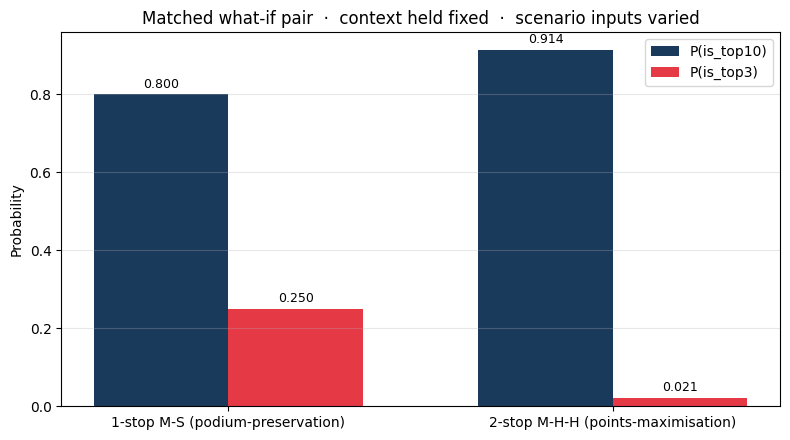

In [22]:
# ===== Step 5 — Side-by-side plot =====
fig, ax = plt.subplots(figsize=(8, 4.5))

labels = list(out["scenario_label"])
x = np.arange(len(labels))
width = 0.35

primary_vals = out[f"P({PRIMARY_TARGET})"].values
ax.bar(x - width/2, primary_vals, width, label=f"P({PRIMARY_TARGET})", color="#1A3A5C")
for xi, v in zip(x - width/2, primary_vals):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

if EXPANSION_IS_BINARY:
    exp_vals = out[f"P({EXPANSION_TARGET})"].values
    exp_label = f"P({EXPANSION_TARGET})"
else:
    exp_vals = out[f"pred({EXPANSION_TARGET})"].values
    exp_label = f"pred({EXPANSION_TARGET})"

ax.bar(x + width/2, exp_vals, width, label=exp_label, color="#E63946")
for xi, v in zip(x + width/2, exp_vals):
    ax.text(xi, v + (0.01 if EXPANSION_IS_BINARY else 0.05), f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Probability" if EXPANSION_IS_BINARY else "Mixed scale (probability + prediction)")
ax.set_title(f"Matched what-if pair  ·  context held fixed  ·  scenario inputs varied")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6 — Interpretation (write this in your team's words)

Fill in the four placeholders below with concrete numbers from your run. **Use scenario-conditioned language**, not causal language. Then commit this notebook to your repo.

> **Driver-race context (held fixed):** Sergio Pérez (Red Bull), Hungarian Grand Prix 2023, grid position 9 (midfield). Red Bull prior3 avg finish ≈ 3rd; Pérez prior3 avg finish ≈ 7th.
>
> **Strategy inputs varied:** `n_stops` (1 vs 2) and `compound_sequence` ("M-S" vs "M-H-H").
>
> **Result:** Under our model and our 2019–2021 training distribution, holding the pre-race driver-race context fixed:
> - For target `is_top10`: P(top10 | 1-stop M-S) = 0.8000 vs P(top10 | 2-stop M-H-H) = 0.9136 → preferred scenario: **2-stop M-H-H** (+11.36pp)
> - For target `is_top3`: P(top3 | 1-stop M-S) = 0.2500 vs P(top3 | 2-stop M-H-H) = 0.0213 → preferred scenario: **1-stop M-S** (+22.87pp)
>
> **The two targets exhibit CRITICAL DISAGREEMENT: is_top10 prefers the 2-stop M-H-H, but is_top3 strongly prefers the 1-stop M-S.**
>
> **What this means for our advisor:** This is a critical trade-off case. If an advisor consulted only `is_top10`, it would enthusiastically recommend the 2-stop M-H-H strategy to maximize points probability, completely missing that doing so collapses the podium probability from 25.00% to just 2.13%—a severe 22.87 percentage-point loss. The 1-stop M-S strategy is riskier for just finishing in the top 10 (dropping from 91% to 80%), but it preserves the podium possibility. This reveals why `is_top3` is essential as an expansion target. The disagreement is not a model failure; it is a decision signal. For a driver-constructor pair with genuine podium aspirations at Hungary (like Red Bull at this phase of 2023), the team must consciously decide whether they are defending points (choose 2-stop) or hunting for a podium (choose 1-stop).
>
> **What we still don't know:** Whether this recommendation holds if actual pit-stop delta, tire degradation, or relative car competitiveness against specific competitors differs on race day—our model conditions only on pre-race form and grid position, not dynamic race incidents (safety cars, incidents, weather changes). Additionally, the training data spans 2019–2021 where strategy philosophy and pit timings may have shifted; the 2023 test data applies 2023–2024 pit assumptions, which may not persist into future seasons.

---
